In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

In [ ]:
df = pd.read_csv("Sample_Superstore.csv", encoding="latin1")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
df.isnull().sum()


,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [ ]:
df.describe()

,Row ID,Order Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


Total Sales: 2,297,201
Total Profit: 286,397
Profit Margin: 12.47%
AOV: 458.61


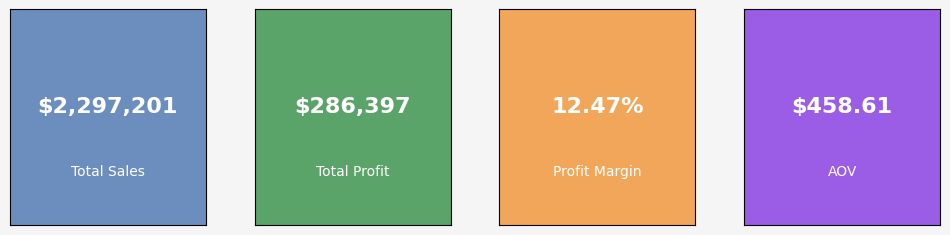

In [ ]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
profit_margin = total_profit / total_sales
aov = df["Sales"].sum() / df["Order ID"].nunique()

print(f"Total Sales: {total_sales:,.0f}")
print(f"Total Profit: {total_profit:,.0f}")
print(f"Profit Margin: {profit_margin:.2%}")
print(f"AOV: {aov:,.2f}")

from matplotlib.patches import FancyBboxPatch

fig, axes = plt.subplots(1, 4, figsize=(12, 2.8))
fig.patch.set_facecolor('#f5f5f5')

titles = ["Total Sales", "Total Profit", "Profit Margin", "AOV"]
values = [
    f"${total_sales:,.0f}",
    f"${total_profit:,.0f}",
    f"{profit_margin:.2%}",
    f"${aov:,.2f}"
]

colors = ["#6C8EBF", "#5AA469", "#F2A65A", "#9B5DE5"]

for i, ax in enumerate(axes):
    ax.set_facecolor(colors[i])

    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.text(0.5, 0.55, values[i],
            ha='center', va='center',
            fontsize=16, color='white', fontweight='bold')

    ax.text(0.5, 0.25, titles[i],
            ha='center', va='center',
            fontsize=10, color='white')

plt.subplots_adjust(wspace=0.25)

plt.show()

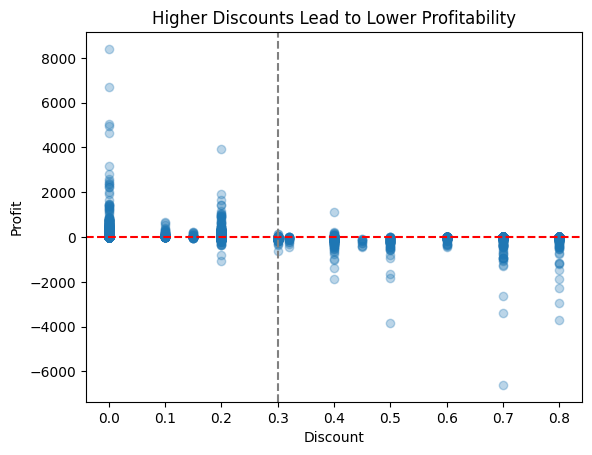

In [ ]:
plt.scatter(df["Discount"], df["Profit"], alpha=0.3)

plt.axhline(0, color='red', linestyle='--')
plt.axvline(0.3, color='gray', linestyle='--')

plt.xlabel("Discount")
plt.ylabel("Profit")
plt.title("Higher Discounts Lead to Lower Profitability")

plt.show()

When discounts exceed approximately 30%, profits decline significantly, and a large number of orders result in losses, indicating that excessive discounting is a major cause of the decline in profits.

In [ ]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Day"] = df["Order Date"].dt.day

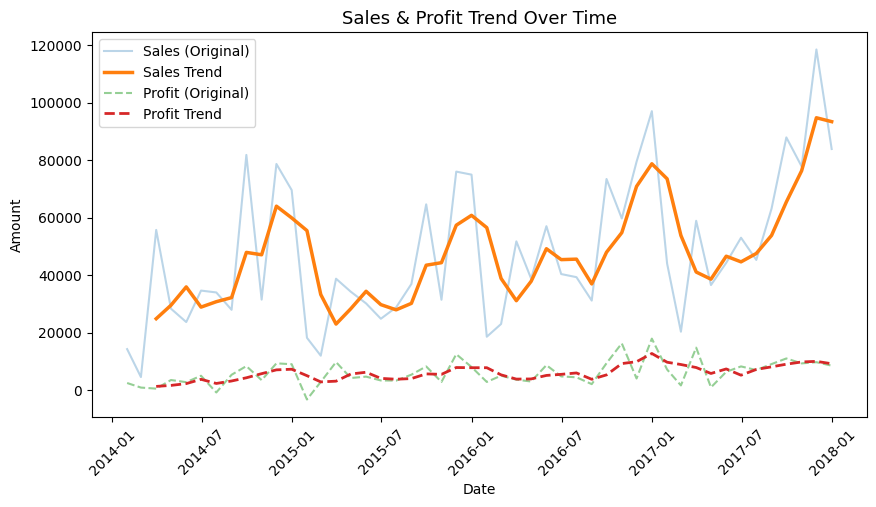

In [ ]:
monthly_sales = df.resample("ME", on="Order Date")["Sales"].sum()
monthly_profit = df.resample("ME", on="Order Date")["Profit"].sum()

sales_smooth = monthly_sales.rolling(3).mean()
profit_smooth = monthly_profit.rolling(3).mean()

plt.figure(figsize=(10,5))

plt.plot(monthly_sales.index, monthly_sales.values,
         alpha=0.3, label="Sales (Original)")

plt.plot(monthly_sales.index, sales_smooth,
         linewidth=2.5, label="Sales Trend")

plt.plot(monthly_profit.index, monthly_profit.values,
         linestyle="--", alpha=0.5, label="Profit (Original)")

plt.plot(monthly_profit.index, profit_smooth,
         linewidth=2, linestyle="--", label="Profit Trend")

plt.title("Sales & Profit Trend Over Time", fontsize=13)
plt.xlabel("Date")
plt.ylabel("Amount")

plt.legend()
plt.xticks(rotation=45)

plt.show()

Sales exhibit a clear upward trend over time, indicating consistent business growth.
However, profit increases at a slower rate compared to sales, suggesting that revenue growth is not translating proportionally into profitability.
This may be due to high discount levels, which compress profit margins.
In addition, sales show significant volatility and recurring peaks, indicating the presence of seasonal patterns.
Sales tend to peak towards the end of each year, likely driven by holiday demand.

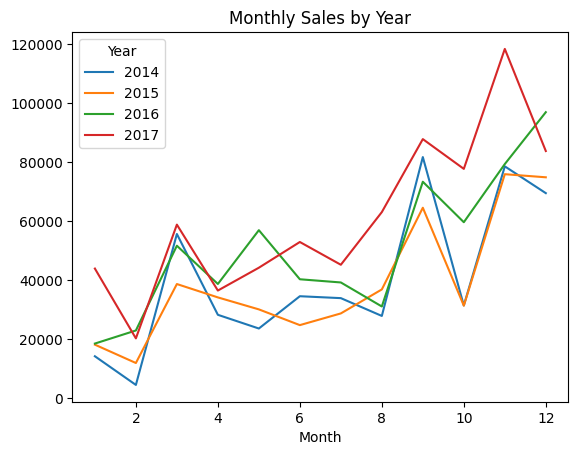

In [ ]:
pivot = df.pivot_table(
    values="Sales",
    index="Month",
    columns="Year",
    aggfunc="sum"
)

pivot.plot()
plt.title("Monthly Sales by Year")
plt.show()

Sales exhibit a clear seasonal pattern across all years.
They are generally lower at the beginning of the year, fluctuate during mid-year, and increase significantly towards the end of the year.
This pattern is consistent across multiple years, indicating strong and recurring seasonal demand.
Additionally, sales in 2017 are consistently higher than in previous years, suggesting sustained business growth.

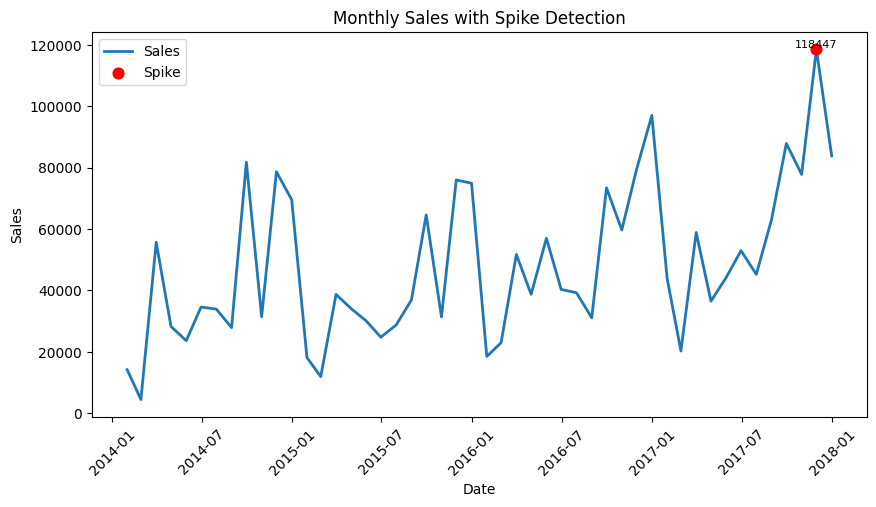

Detected spikes:
Order Date
2017-11-30    118447.825
Freq: ME, Name: Sales, dtype: float64


In [ ]:
mean = monthly_sales.mean()
std = monthly_sales.std()
z_scores = (monthly_sales - mean) / std

spikes = monthly_sales[abs(z_scores) > 2]

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values,
         label="Sales", linewidth=2)
plt.scatter(spikes.index, spikes.values,
            color="red", s=60, label="Spike", zorder=3)

for x, y in zip(spikes.index, spikes.values):
    plt.text(x, y, f"{int(y)}", fontsize=8, ha='center', va='bottom')

plt.title("Monthly Sales with Spike Detection")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.xticks(rotation=45)

plt.show()

print("Detected spikes:")
print(spikes)

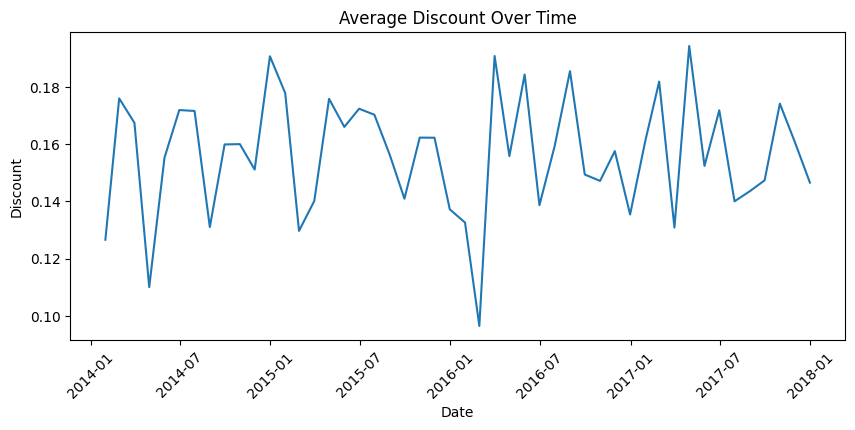

In [ ]:
monthly_discount = df.resample("ME", on="Order Date")["Discount"].mean()

plt.figure(figsize=(10,4))
plt.plot(monthly_discount.index, monthly_discount.values)

plt.title("Average Discount Over Time")
plt.xlabel("Date")
plt.ylabel("Discount")

plt.xticks(rotation=45)
plt.show()

From a temporal perspective, discount levels have fluctuated relatively steadily overall, showing no clear upward trend or seasonal pattern. During the period of the sales anomaly (November 2017), discount levels were not significantly higher than in other periods, indicating that this sales anomaly was not primarily driven by discounts.

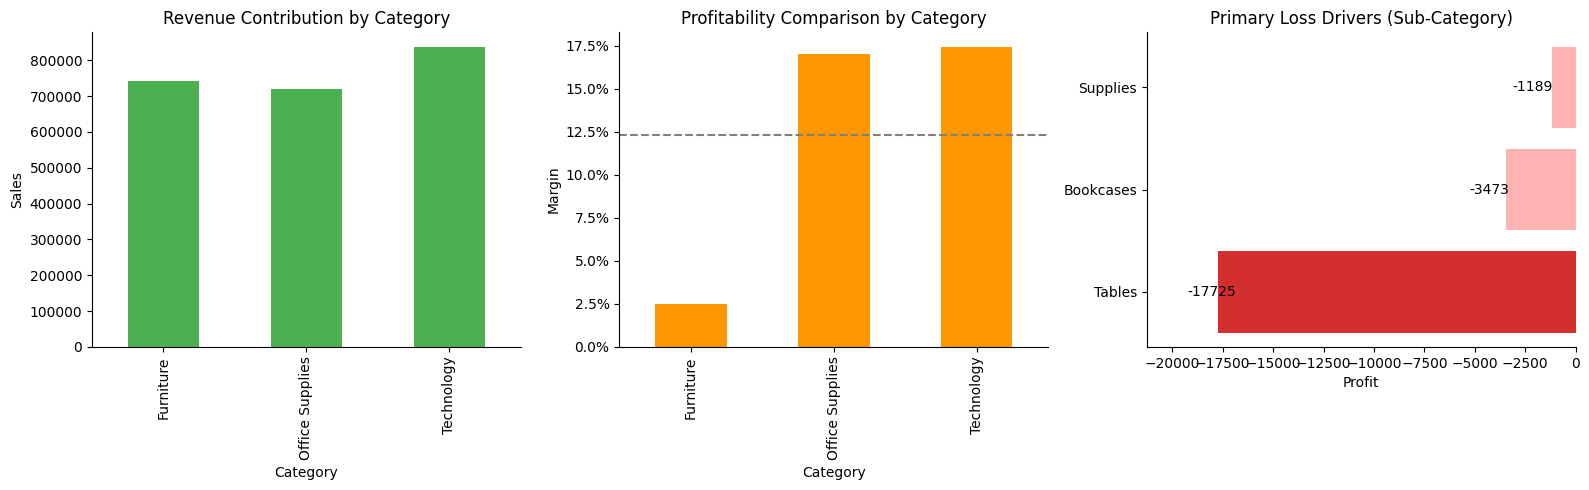

In [ ]:
category_sales = df.groupby("Category")["Sales"].sum()
category_profit = df.groupby("Category")["Profit"].sum()

category_margin = category_profit / category_sales

structure = df.groupby(["Category", "Sub-Category"]).agg({
    "Sales": "sum",
    "Profit": "sum"
}).reset_index()

loss_sub = structure[structure["Profit"] < 0].sort_values("Profit")

fig, axes = plt.subplots(1, 3, figsize=(16,5))

category_sales.plot(
    kind="bar",
    ax=axes[0],
    color="#4CAF50"
)
axes[0].set_title("Revenue Contribution by Category")
axes[0].set_ylabel("Sales")

category_margin.plot(
    kind="bar",
    ax=axes[1],
    color="#FF9800"
)
axes[1].set_title("Profitability Comparison by Category")
axes[1].set_ylabel("Margin")

axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

axes[1].axhline(category_margin.mean(), color='gray', linestyle='--')

loss_sub = loss_sub.sort_values("Profit")

colors = ["#D32F2F" if x == "Tables" else "#FFB3B3" for x in loss_sub["Sub-Category"]]

axes[2].barh(loss_sub["Sub-Category"], loss_sub["Profit"], color=colors)

axes[2].set_title("Primary Loss Drivers (Sub-Category)")
axes[2].set_xlabel("Profit")

axes[2].set_xlim(loss_sub["Profit"].min() * 1.2, 0)

for i, v in enumerate(loss_sub["Profit"]):
    axes[2].text(v * 0.95, i, f"{v:.0f}", va='center', ha='right')


for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

Although sales are distributed relatively evenly across categories, there are significant differences in profitability, with the Furniture category having the lowest profit margin. Further analysis reveals that the losses are primarily concentrated in the Tables subcategory.


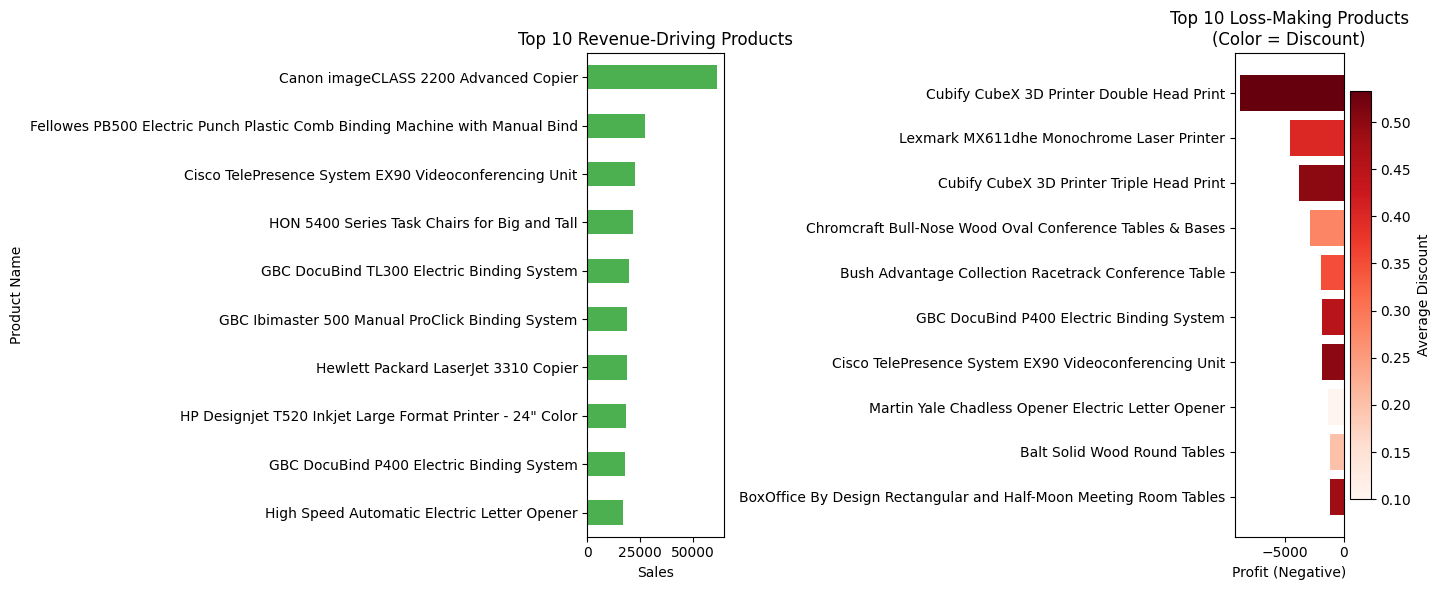

In [ ]:
top_products = df.groupby("Product Name")["Sales"].sum() \
                 .sort_values(ascending=False).head(10)

loss_products = df.groupby("Product Name").agg({
    "Profit": "sum",
    "Discount": "mean"
}).sort_values(by="Profit").head(10)

norm = plt.Normalize(loss_products["Discount"].min(),
                     loss_products["Discount"].max())
colors = plt.cm.Reds(norm(loss_products["Discount"]))

fig, axes = plt.subplots(1, 2, figsize=(14,6))

top_products.plot(kind="barh", ax=axes[0], color="#4CAF50")
axes[0].set_title("Top 10 Revenue-Driving Products")
axes[0].set_xlabel("Sales")
axes[0].invert_yaxis()

axes[1].barh(loss_products.index, loss_products["Profit"], color=colors)
axes[1].set_title("Top 10 Loss-Making Products\n(Color = Discount)")
axes[1].set_xlabel("Profit (Negative)")
axes[1].invert_yaxis()

sm = plt.cm.ScalarMappable(cmap="Reds", norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=axes[1])
cbar.set_label("Average Discount")

plt.tight_layout()
plt.show()

Revenue is highly concentrated in a small number of products, indicating that the company is heavily reliant on its core offerings.
At the same time, a number of products continue to generate losses, many of which are subject to significant discounts. This suggests that aggressive discounting strategies may be eroding profitability. However, discounts alone do not fully explain this issue, indicating that there are deeper-rooted pricing or cost-efficiency problems.

In [ ]:
df.groupby("Sub-Category").agg({
    "Profit": "sum",
    "Discount": "mean",
    "Sales": "sum"
}).sort_values("Profit").head(10)

,Profit,Discount,Sales
Sub-Category,,,
Tables,-17725.4811,0.261285,206965.5320
Bookcases,-3472.5560,0.211140,114879.9963
Supplies,-1189.0995,0.076842,46673.5380
Fasteners,949.5182,0.082028,3024.2800
Machines,3384.7569,0.306087,189238.6310
Labels,5546.2540,0.068681,12486.3120
Art,6527.7870,0.074874,27118.7920
Envelopes,6964.1767,0.080315,16476.4020
Furnishings,13059.1436,0.138349,91705.1640


Although the "Tables" subcategory has high sales, it also reports the most significant losses. At the same time, its discount rates are relatively high, suggesting that discounts may have had some impact on profitability.
Although there is a certain correlation between higher discounts and lower profits, discounts alone cannot fully explain the losses. For example, the "Supplies" subcategory still incurred losses despite having lower discounts, suggesting that other factors, such as pricing structures or cost efficiency, may also be at play. This indicates that profitability issues may result from the combined effect of multiple factors rather than a single cause.

Based on the analysis, the product strategy should focus on three key areas.
First, priority should be given to providing inventory and marketing support for high-performing products that contribute significantly to total revenue, as business performance depends largely on a small number of core products.
Second, the desk and chair category urgently needs optimization. Despite strong sales volume, this category is generating substantial losses, indicating potential issues with pricing or cost structure. Rather than discontinuing products, it is advisable to re-evaluate and adjust discount and pricing strategies.
Finally, for subcategories such as bookcases and office supplies—which are not only heavily loss-making but also contribute little to sales—a careful assessment should be conducted to determine whether there is room for improvement or if they should be phased out.

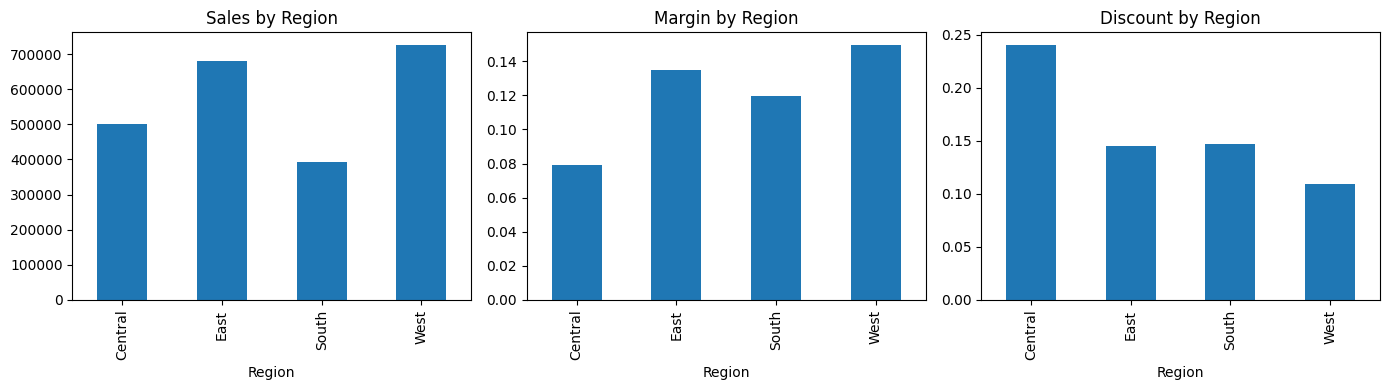

In [ ]:
region = df.groupby("Region").agg({
    "Sales": "sum",
    "Profit": "sum",
    "Discount": "mean"
})
region["Margin"] = region["Profit"] / region["Sales"]

fig, axes = plt.subplots(1,3, figsize=(14,4))
region["Sales"].plot(kind="bar", ax=axes[0], title="Sales by Region")
region["Margin"].plot(kind="bar", ax=axes[1], title="Margin by Region")
region["Discount"].plot(kind="bar", ax=axes[2], title="Discount by Region")
plt.tight_layout(); plt.show()

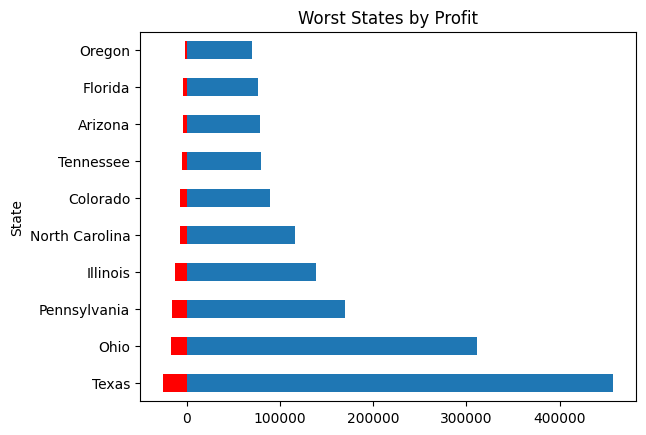

In [ ]:
state = df.groupby("State").agg({
    "Sales": "sum",
    "Profit": "sum"
})

state["Sales"].sort_values(ascending=False).head(10).plot(kind="barh", title="Top States by Sales")

state["Profit"].sort_values().head(10).plot(kind="barh", color="red", title="Worst States by Profit")
plt.show()

In [ ]:
from IPython.display import display

city_profit = df.groupby("City")["Profit"].sum().sort_values().head(5)
state_discount = df.groupby("State")["Discount"].mean().sort_values(ascending=False).head(10)

display(city_profit.to_frame(name="Profit"), state_discount.to_frame(name="Avg Discount"))

,Profit
City,
Philadelphia,-13837.7674
Houston,-10153.5485
San Antonio,-7299.0502
Lancaster,-7239.0684
Chicago,-6654.5688


,Avg Discount
State,
Illinois,0.390041
Texas,0.370193
Pennsylvania,0.328620
Ohio,0.324947
Colorado,0.316484
Arizona,0.303571
Florida,0.299347
Tennessee,0.291257
Oregon,0.288710


Regional analysis shows that while sales in the West and East are relatively strong, there are significant disparities in profitability. The Central region has the lowest profit margins and the highest discount rates, suggesting that discounts may be impacting profitability.
At the state level, losses are highly concentrated in a few states, particularly Texas and Ohio, both of which also have high discount rates.
Analysis at the city level further confirms that losses are concentrated in specific areas rather than distributed evenly.

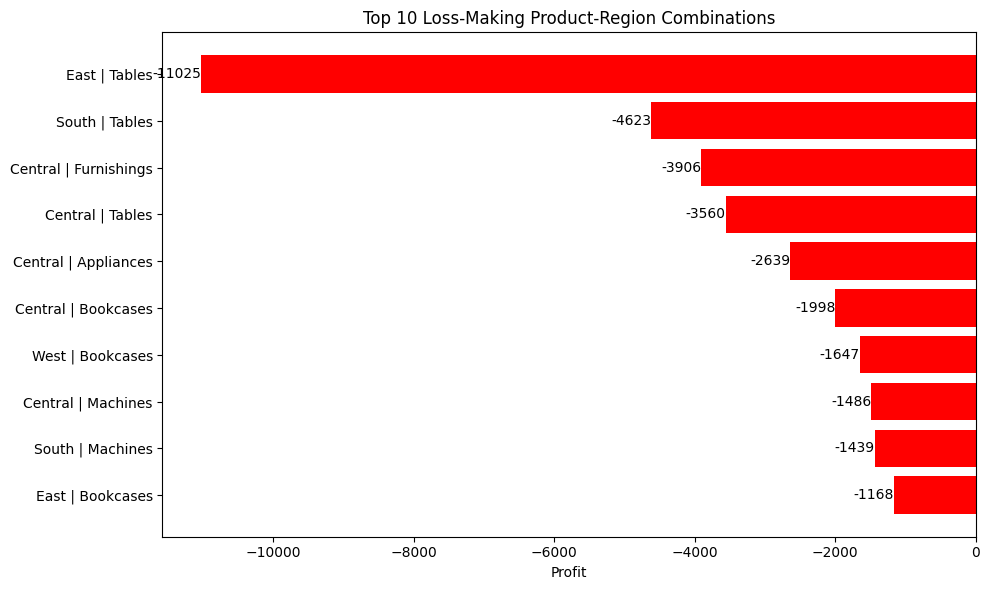

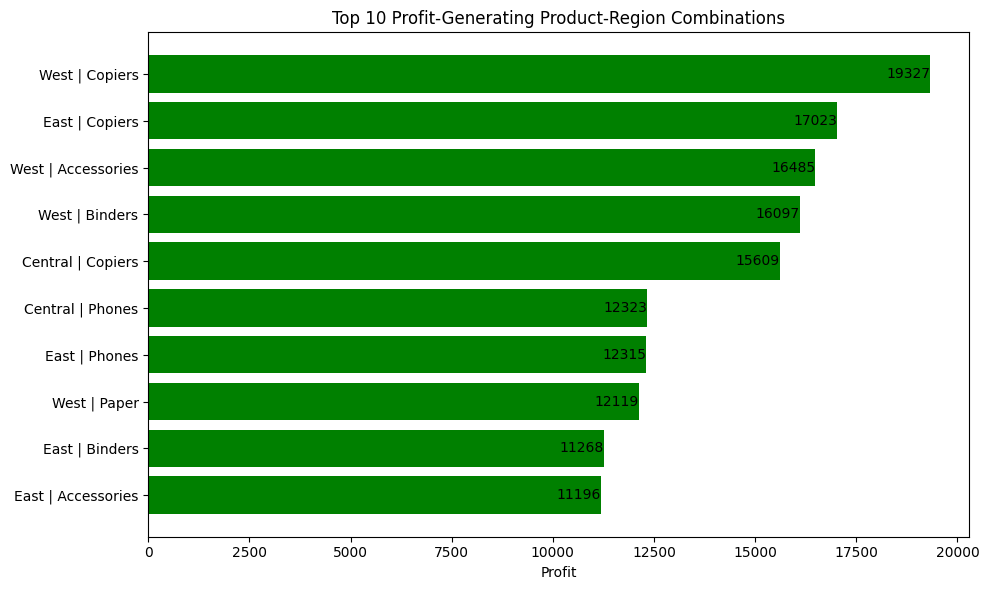

🔻 Worst Product-Region Combinations:


,Region,Sub-Category,Sales,Profit,Discount
33,East,Tables,39139.8070,-11025.3801,0.373750
50,South,Tables,43916.1920,-4623.0579,0.222549
9,Central,Furnishings,15254.3700,-3906.2168,0.403902
16,Central,Tables,39154.9710,-3559.6504,0.262500
1,Central,Appliances,23582.0330,-2638.6175,0.448780
4,Central,Bookcases,24157.1768,-1997.9043,0.232800
55,West,Bookcases,36004.1235,-1646.5117,0.228750
11,Central,Machines,26797.3840,-1486.0666,0.328571
45,South,Machines,53890.9600,-1438.8930,0.333333
21,East,Bookcases,43819.3340,-1167.6318,0.220000



🟢 Best Product-Region Combinations:


,Region,Sub-Category,Sales,Profit,Discount
57,West,Copiers,49749.242,19327.2351,0.144000
23,East,Copiers,53219.462,17022.8418,0.250000
51,West,Accessories,61114.116,16484.5983,0.036434
54,West,Binders,55961.113,16096.8016,0.281741
6,Central,Copiers,37259.570,15608.8413,0.112500
13,Central,Phones,72403.282,12323.0267,0.122000
30,East,Phones,100614.982,12314.6860,0.160294
63,West,Paper,26663.718,12119.2364,0.031556
20,East,Binders,53497.997,11267.9346,0.353409
17,East,Accessories,45033.372,11195.8644,0.085437


In [ ]:
cross = df.groupby(["Region", "Sub-Category"]).agg({
    "Sales": "sum",
    "Profit": "sum",
    "Discount": "mean"
}).reset_index()

worst_combo = cross.sort_values("Profit").head(10)

best_combo = cross.sort_values("Profit", ascending=False).head(10)

plt.figure(figsize=(10,6))

labels = worst_combo["Region"] + " | " + worst_combo["Sub-Category"]
colors = ["red" if p < 0 else "green" for p in worst_combo["Profit"]]

plt.barh(labels, worst_combo["Profit"], color=colors)

for i, v in enumerate(worst_combo["Profit"]):
    plt.text(v, i, f"{v:.0f}", va='center', ha='right')

plt.title("Top 10 Loss-Making Product-Region Combinations")
plt.xlabel("Profit")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))

labels2 = best_combo["Region"] + " | " + best_combo["Sub-Category"]

plt.barh(labels2, best_combo["Profit"], color="green")

for i, v in enumerate(best_combo["Profit"]):
    plt.text(v, i, f"{v:.0f}", va='center', ha='right')

plt.title("Top 10 Profit-Generating Product-Region Combinations")
plt.xlabel("Profit")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

print("🔻 Worst Product-Region Combinations:")
display(worst_combo)

print("\n🟢 Best Product-Region Combinations:")
display(best_combo)

A cross-analysis of products and regions reveals that the losses are not caused by a single factor, but are driven by the combination of "product + region."
Tables are generating losses across multiple regions, most notably in the East and South, indicating systemic issues with this product category.
Meanwhile, the Central region faces broader challenges, with multiple subcategories (such as Furnishings and Appliances) performing poorly.
These losses are typically accompanied by high discount levels, suggesting that excessive promotions may be eroding profits. Furthermore, discount strategies are inconsistent, with some locations offering excessive discounts while others maintain better control.

Reevaluate pricing and discount strategies for office desks across all regions. Conduct an in-depth investigation into broader structural issues in the Central Region, including pricing, demand, and cost structures. Expand business in high-margin product categories such as copiers and supplies. Implement more targeted and region-specific discount strategies.

In [ ]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

snapshot_date = df["Order Date"].max() + pd.Timedelta(days=1)

rfm = df.groupby("Customer Name").agg({
    "Order Date": lambda x: (snapshot_date - x.max()).days,
    "Order ID": "count",
    "Sales": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm["R_score"] = pd.qcut(rfm["Recency"], 4, labels=[4,3,2,1])
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 4, labels=[1,2,3,4])
rfm["M_score"] = pd.qcut(rfm["Monetary"], 4, labels=[1,2,3,4])

rfm["RFM_score"] = rfm["R_score"].astype(str) + rfm["F_score"].astype(str) + rfm["M_score"].astype(str)

def segment(row):
    if row["R_score"] >= 3 and row["F_score"] >= 3 and row["M_score"] >= 3:
        return "High Value"
    elif row["F_score"] >= 3:
        return "Loyal"
    elif row["R_score"] == 1:
        return "At Risk"
    else:
        return "Normal"

rfm["Customer Type"] = rfm.apply(segment, axis=1)

,Sales,Profit,Num Customers
Customer Type,,,
At Risk,179942.4149,19034.8978,132
High Value,850975.0144,99267.5101,187
Loyal,760254.3183,104436.0344,209
Normal,506029.1127,63658.5794,265


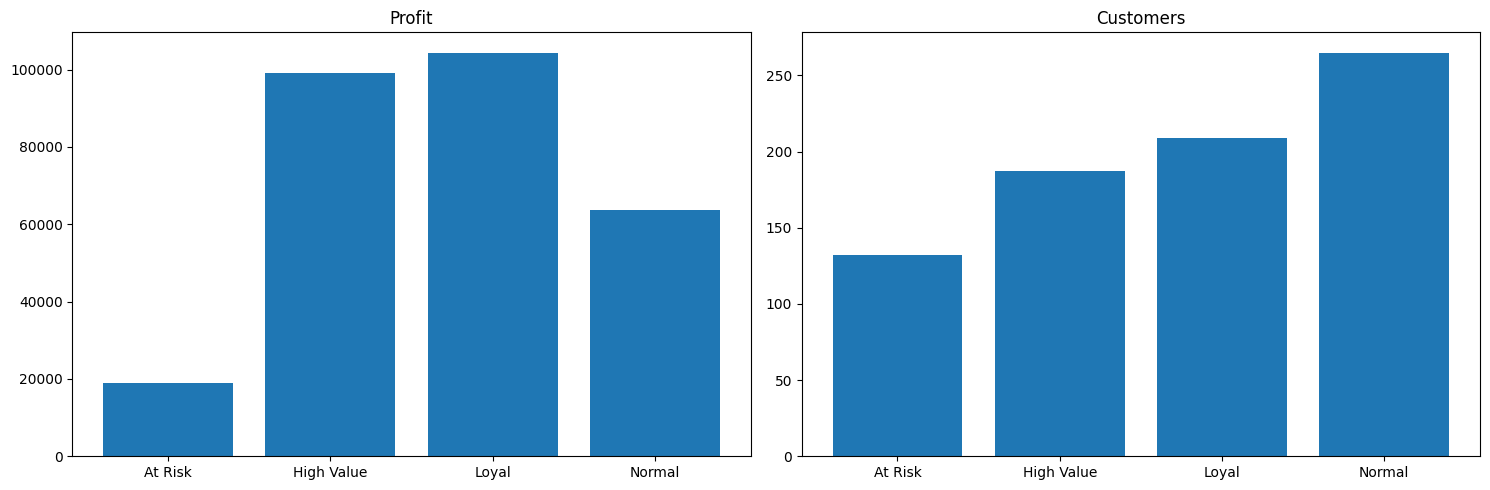

In [ ]:
df = df.merge(
    rfm[["Customer Type"]],
    on="Customer Name",
    how="left"
)

summary = df.groupby("Customer Type").agg({
    "Sales": "sum",
    "Profit": "sum"
})

summary["Num Customers"] = df.groupby("Customer Type")["Customer Name"].nunique()

display(summary)

fig, axes = plt.subplots(1, 2, figsize=(15,5))

axes[0].bar(summary.index, summary["Profit"])
axes[0].set_title("Profit")

axes[1].bar(summary.index, summary["Num Customers"])
axes[1].set_title("Customers")

plt.tight_layout()
plt.show()

,AOV
Customer Type,
At Risk,350.127103
High Value,551.577703
Loyal,512.933224
Normal,408.801137


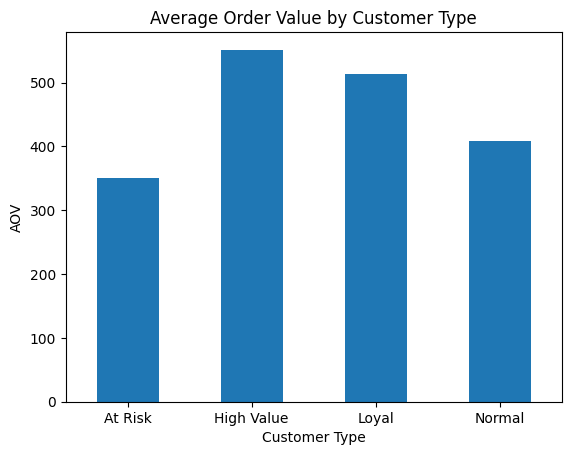

In [ ]:
customer = df.groupby("Customer Name").agg({
    "Sales": "sum",
    "Profit": "sum",
    "Order ID": "nunique"
}).rename(columns={"Order ID": "Orders"})

customer["AOV"] = customer["Sales"] / customer["Orders"]
customer = customer.merge(
    rfm[["Customer Type"]],
    on="Customer Name",
    how="left"
)

aov_summary = customer.groupby("Customer Type")["AOV"].mean()

display(aov_summary)

aov_summary.plot(kind="bar", title="Average Order Value by Customer Type")
plt.ylabel("AOV")
plt.xticks(rotation=0)
plt.show()

,Sales,Profit,Orders,CLV,AOV
Customer Name,,,,,
Tamara Chand,19052.218,8981.3239,5,8981.3239,3810.443600
Raymond Buch,15117.339,6976.0959,6,6976.0959,2519.556500
Sanjit Chand,14142.334,5757.4119,9,5757.4119,1571.370444
Hunter Lopez,12873.298,5622.4292,6,5622.4292,2145.549667
Adrian Barton,14473.571,5444.8055,10,5444.8055,1447.357100
Tom Ashbrook,14595.620,4703.7883,4,4703.7883,3648.905000
Christopher Martinez,8954.020,3899.8904,4,3899.8904,2238.505000
Keith Dawkins,8181.256,3038.6254,12,3038.6254,681.771333
Andy Reiter,6608.448,2884.6208,6,2884.6208,1101.408000


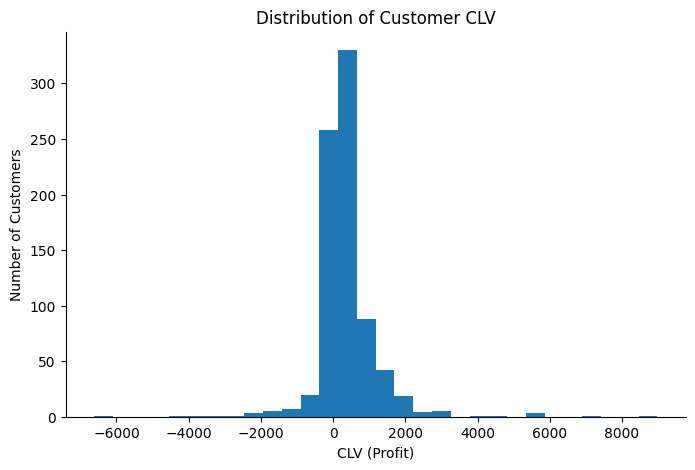

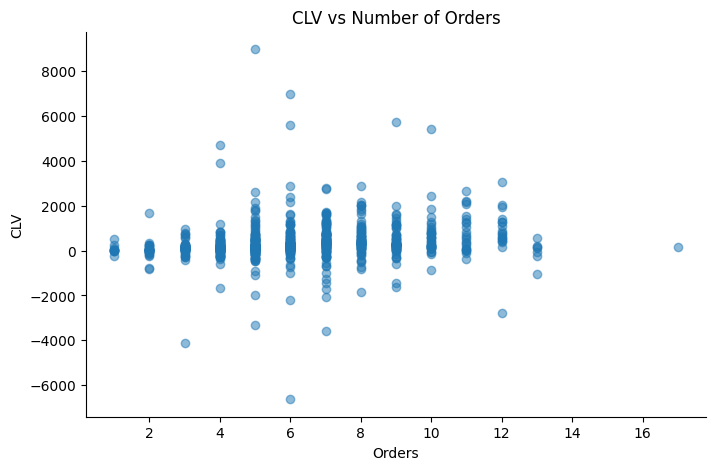

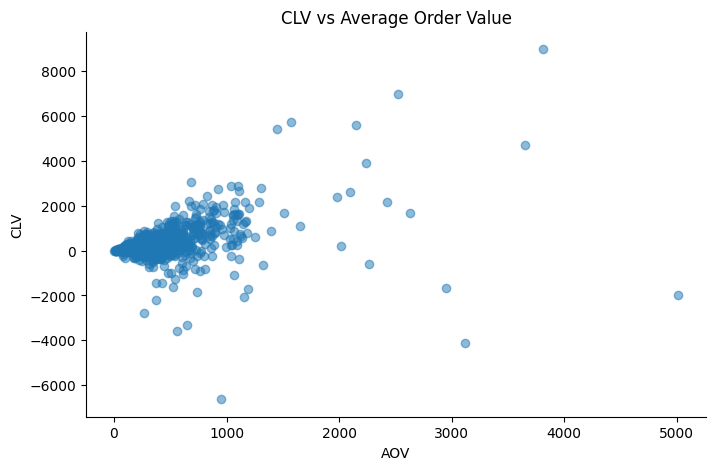

,CLV
Customer Type,
At Risk,144.203771
High Value,530.842300
Loyal,499.693944
Normal,240.221054


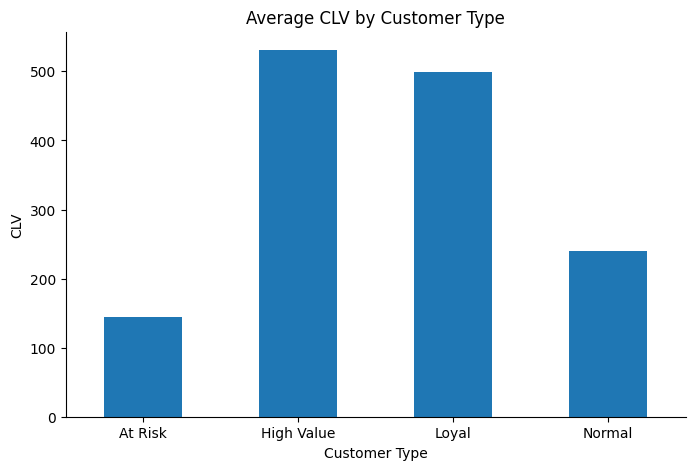

In [ ]:
# =========================
# 1. Calculate CLV
# =========================
clv = df.groupby("Customer Name").agg({
    "Sales": "sum",
    "Profit": "sum",
    "Order ID": "nunique"
}).rename(columns={"Order ID": "Orders"})

clv["CLV"] = clv["Profit"]

clv["AOV"] = clv["Sales"] / clv["Orders"]

clv = clv.sort_values("CLV", ascending=False)

display(clv.head(10))


# =========================
# 2. CLV Distribution
# =========================
plt.figure(figsize=(8,5))
plt.hist(clv["CLV"], bins=30)

plt.title("Distribution of Customer CLV")
plt.xlabel("CLV (Profit)")
plt.ylabel("Number of Customers")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()


# =========================
# 3. CLV vs Orders
# =========================
plt.figure(figsize=(8,5))
plt.scatter(clv["Orders"], clv["CLV"], alpha=0.5)

plt.title("CLV vs Number of Orders")
plt.xlabel("Orders")
plt.ylabel("CLV")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()


# =========================
# 4. CLV vs AOV
# =========================
plt.figure(figsize=(8,5))
plt.scatter(clv["AOV"], clv["CLV"], alpha=0.5)

plt.title("CLV vs Average Order Value")
plt.xlabel("AOV")
plt.ylabel("CLV")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()


# =========================
# 5. CLV Validation (by Customer Type)
# =========================
customer_clv = customer.merge(
    clv[["CLV"]],
    left_index=True,
    right_index=True
)

clv_by_type = customer_clv.groupby("Customer Type")["CLV"].mean()

display(clv_by_type)

clv_by_type.plot(kind="bar", figsize=(8,5))

plt.title("Average CLV by Customer Type")
plt.ylabel("CLV")
plt.xticks(rotation=0)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

CLV analysis indicates that customer value is highly unevenly distributed, with a small number of customers contributing the majority of profits. Although both purchase frequency and average order value have a positive impact on CLV, neither factor alone guarantees profitability. At the same time, the CLV results validate the effectiveness of customer segmentation, confirming that high-value customers are indeed the primary source of business value.

,Segment,Customer Type,Sales,Profit
0,Consumer,At Risk,92033.2476,7907.7502
1,Consumer,High Value,445714.4777,48844.7439
2,Consumer,Loyal,366492.8248,42833.8145
3,Consumer,Normal,257160.7949,34532.9006
4,Corporate,At Risk,56828.7225,7835.7134
5,Corporate,High Value,275099.1552,30991.3092
6,Corporate,Loyal,227241.4933,39954.6794
7,Corporate,Normal,146976.9958,13197.4320
8,Home Office,At Risk,31080.4448,3291.4342
9,Home Office,High Value,130161.3815,19431.4570


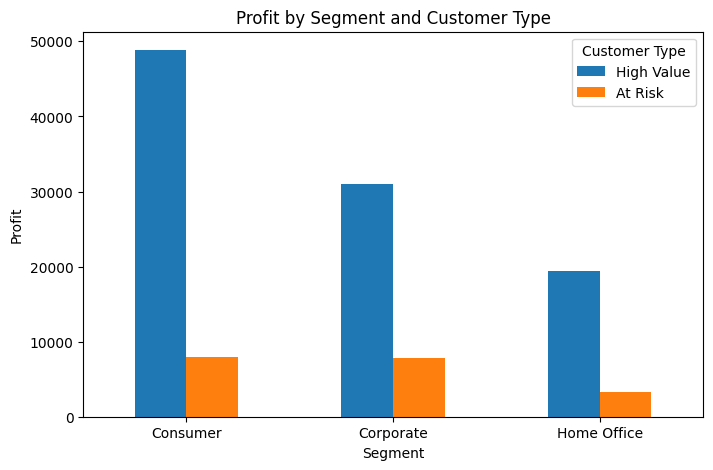

In [ ]:
cross_summary = df.groupby(["Segment", "Customer Type"]).agg({
    "Sales": "sum",
    "Profit": "sum"
}).reset_index()

display(cross_summary)

pivot_profit = cross_summary.pivot(
    index="Segment",
    columns="Customer Type",
    values="Profit"
)

pivot_profit[["High Value", "At Risk"]].plot(kind="bar", figsize=(8,5))

plt.title("Profit by Segment and Customer Type")
plt.ylabel("Profit")
plt.xticks(rotation=0)

plt.show()

The Consumer segment generates the highest profits (High Value) but also incurs the largest losses (Unprofitable), so it falls into the high-return, high-risk category.
The Corporate segment has moderate profits and moderate losses, making it relatively stable.
The Home Office segment has the lowest profits but also the smallest losses, so it is small in scale and has limited impact.
The Consumer customer base contributes the highest profits while also generating the largest losses, indicating that this segment presents both potential and risk, and requires a focus on optimizing management strategies.

In [ ]:
!pip install pandasql

  Preparing metadata (setup.py) ... done
  Created wheel for pandasql: filename=pandasql-0.7.3-py3-none-any.whl size=26773 sha256=3430ba7d2f984f82193f33680cbe143736129c1062f7f93b56c7e112c9ccfc42
  Stored in directory: /root/.cache/pip/wheels/15/a1/e7/6f92f295b5272ae5c02365e6b8fa19cb93f16a537090a1cf27
Successfully built pandasql


In [ ]:
from pandasql import sqldf
pysqldf = lambda q: sqldf(q, globals())

In [ ]:
query = """
SELECT
    "Customer Name",
    SUM(Sales) AS total_sales,
    SUM(Profit) AS total_profit,
    COUNT(DISTINCT "Order ID") AS orders,
    AVG(Discount) AS avg_discount,

    CASE
        WHEN SUM(Profit) > 5000 THEN 'High Value'
        WHEN SUM(Profit) > 0 THEN 'Normal'
        ELSE 'Unprofitable'
    END AS customer_segment
FROM df
GROUP BY "Customer Name"
ORDER BY total_profit DESC
"""

result = pysqldf(query)
result

,Customer Name,total_sales,total_profit,orders,avg_discount,customer_segment
0,Tamara Chand,19052.218,8981.3239,5,0.116667,High Value
1,Raymond Buch,15117.339,6976.0959,6,0.094444,High Value
2,Sanjit Chand,14142.334,5757.4119,9,0.063636,High Value
3,Hunter Lopez,12873.298,5622.4292,6,0.018182,High Value
4,Adrian Barton,14473.571,5444.8055,10,0.240000,High Value
...,...,...,...,...,...,...
788,Henry Goldwyn,3247.642,-2797.9635,12,0.170588,Unprofitable
789,Sharelle Roach,3233.481,-3333.9144,5,0.366667,Unprofitable
790,Luke Foster,3930.509,-3583.9770,7,0.318750,Unprofitable
791,Grant Thornton,9351.212,-4108.6589,3,0.250000,Unprofitable


In [ ]:
query = """
SELECT
    CASE
        WHEN Discount <= 0.2 THEN 'Low'
        WHEN Discount <= 0.5 THEN 'Medium'
        ELSE 'High'
    END AS discount_bucket,

    COUNT(*) AS orders,
    AVG(Profit) AS avg_profit,
    SUM(Profit) AS total_profit,

    SUM(CASE WHEN Profit < 0 THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS loss_rate
FROM df
GROUP BY discount_bucket
ORDER BY discount_bucket
"""

result = pysqldf(query)
result

,discount_bucket,orders,avg_profit,total_profit,loss_rate
0,High,856,-89.438144,-76559.0513,1.000000
1,Low,8601,49.037679,421773.0777,0.060807
2,Medium,537,-109.528873,-58817.0047,0.916201


In [ ]:
query = """
WITH product_profit AS (
    SELECT
        "Product Name",
        SUM(Profit) AS total_profit
    FROM df
    GROUP BY "Product Name"
),
total AS (
    SELECT SUM(total_profit) AS grand_total FROM product_profit
)

SELECT
    p."Product Name",
    p.total_profit,
    p.total_profit * 1.0 / t.grand_total AS profit_ratio
FROM product_profit p, total t
ORDER BY p.total_profit ASC
LIMIT 10
"""

result = pysqldf(query)
result

,Product Name,total_profit,profit_ratio
0,Cubify CubeX 3D Printer Double Head Print,-8879.9704,-0.031006
1,Lexmark MX611dhe Monochrome Laser Printer,-4589.9730,-0.016027
2,Cubify CubeX 3D Printer Triple Head Print,-3839.9904,-0.013408
3,Chromcraft Bull-Nose Wood Oval Conference Tabl...,-2876.1156,-0.010042
4,Bush Advantage Collection Racetrack Conference...,-1934.3976,-0.006754
5,GBC DocuBind P400 Electric Binding System,-1878.1662,-0.006558
6,Cisco TelePresence System EX90 Videoconferenci...,-1811.0784,-0.006324
7,Martin Yale Chadless Opener Electric Letter Op...,-1299.1836,-0.004536
8,Balt Solid Wood Round Tables,-1201.0581,-0.004194
9,BoxOffice By Design Rectangular and Half-Moon ...,-1148.4375,-0.004010


In [ ]:
query = """
SELECT
    "Customer Name",
    total_sales,
    total_profit,
    total_profit * 1.0 / total_sales AS profit_margin,
    DENSE_RANK() OVER (ORDER BY total_profit DESC) AS rank_profit
FROM (
    SELECT
        "Customer Name",
        SUM(Sales) AS total_sales,
        SUM(Profit) AS total_profit
    FROM df
    GROUP BY "Customer Name"
)
ORDER BY total_profit DESC
LIMIT 10
"""

result = pysqldf(query)
result

,Customer Name,total_sales,total_profit,profit_margin,rank_profit
0,Tamara Chand,19052.218,8981.3239,0.471406,1
1,Raymond Buch,15117.339,6976.0959,0.461463,2
2,Sanjit Chand,14142.334,5757.4119,0.407105,3
3,Hunter Lopez,12873.298,5622.4292,0.436751,4
4,Adrian Barton,14473.571,5444.8055,0.376190,5
5,Tom Ashbrook,14595.620,4703.7883,0.322274,6
6,Christopher Martinez,8954.020,3899.8904,0.435546,7
7,Keith Dawkins,8181.256,3038.6254,0.371413,8
8,Andy Reiter,6608.448,2884.6208,0.436505,9
9,Daniel Raglin,8350.868,2869.0760,0.343566,10


In [ ]:
query = """
SELECT
    "Customer Name",
    total_sales,
    total_profit,
    total_profit * 1.0 / total_sales AS profit_margin,
    DENSE_RANK() OVER (ORDER BY total_profit ASC) AS rank_profit
FROM (
    SELECT
        "Customer Name",
        SUM(Sales) AS total_sales,
        SUM(Profit) AS total_profit
    FROM df
    GROUP BY "Customer Name"
)
ORDER BY total_profit ASC
LIMIT 10
"""


result = pysqldf(query)
result

,Customer Name,total_sales,total_profit,profit_margin,rank_profit
0,Cindy Stewart,5690.055,-6626.3895,-1.164556,1
1,Grant Thornton,9351.212,-4108.6589,-0.439372,2
2,Luke Foster,3930.509,-3583.9770,-0.911835,3
3,Sharelle Roach,3233.481,-3333.9144,-1.031060,4
4,Henry Goldwyn,3247.642,-2797.9635,-0.861537,5
5,Nathan Cano,2218.990,-2204.8072,-0.993608,6
6,Sean Braxton,8057.891,-2082.7451,-0.258473,7
7,Sean Miller,25043.050,-1980.7393,-0.079093,8
8,Christine Phan,5888.275,-1850.3029,-0.314235,9
9,Natalie Fritzler,8322.826,-1695.9714,-0.203774,10


In [ ]:
query = """
SELECT
    "Customer Name",
    AVG(Discount) AS avg_discount,
    SUM(Profit) AS total_profit,

    CASE
        WHEN AVG(Discount) > 0.4 THEN 'High Discount'
        ELSE 'Low Discount'
    END AS discount_group
FROM df
GROUP BY "Customer Name"
ORDER BY total_profit DESC
LIMIT 10
"""

result = pysqldf(query)
result

,Customer Name,avg_discount,total_profit,discount_group
0,Tamara Chand,0.116667,8981.3239,Low Discount
1,Raymond Buch,0.094444,6976.0959,Low Discount
2,Sanjit Chand,0.063636,5757.4119,Low Discount
3,Hunter Lopez,0.018182,5622.4292,Low Discount
4,Adrian Barton,0.240000,5444.8055,Low Discount
5,Tom Ashbrook,0.080000,4703.7883,Low Discount
6,Christopher Martinez,0.120000,3899.8904,Low Discount
7,Keith Dawkins,0.087500,3038.6254,Low Discount
8,Andy Reiter,0.066667,2884.6208,Low Discount
9,Daniel Raglin,0.153846,2869.0760,Low Discount


              precision    recall  f1-score   support

           0       0.93      0.79      0.85       130
           1       0.44      0.72      0.55        29

    accuracy                           0.78       159
   macro avg       0.68      0.76      0.70       159
weighted avg       0.84      0.78      0.80       159


Feature Importance:
     Feature  Coefficient
6   Discount     1.283360
2        AOV     0.660584
1     Orders     0.207948
3    Recency     0.177572
4  Frequency    -0.135566
0      Sales    -0.346037
5   Monetary    -0.346037


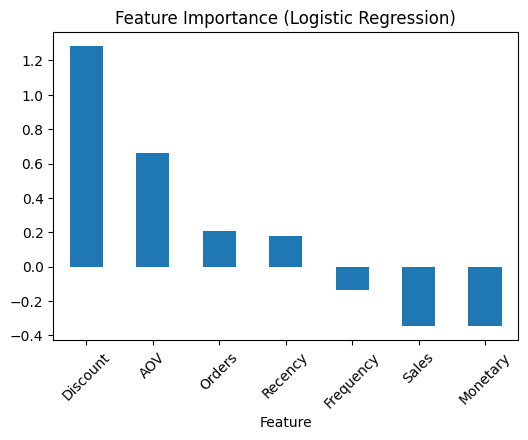


Top High-Risk Customers:


,Sales,Profit,Orders,AOV,Recency,Frequency,Monetary,Discount,Target,Loss_Prob
Customer Name,,,,,,,,,,
Thais Sissman,4.8330,-3.3156,2,2.416500,358,2,4.8330,0.700000,1,0.999524
Ritsa Hightower,740.3820,0.3057,2,370.191000,520,3,740.3820,0.533333,0,0.996727
Gene Hale,1361.2440,-95.4498,2,680.622000,388,3,1361.2440,0.466667,1,0.992908
Vivek Sundaresam,1055.9810,-262.8093,4,263.995250,222,8,1055.9810,0.475000,1,0.987756
Tom Prescott,5329.0048,-1087.3898,5,1065.800960,105,10,5329.0048,0.462000,1,0.986046
Lisa Hazard,318.2390,-242.7399,4,79.559750,240,6,318.2390,0.466667,1,0.985714
Anthony Garverick,170.5840,-8.4310,4,42.646000,78,5,170.5840,0.460000,1,0.981793
Mitch Gastineau,16.7390,-1.2453,1,16.739000,265,2,16.7390,0.450000,1,0.978805
Valerie Takahito,1736.5960,-224.0889,2,868.298000,1001,9,1736.5960,0.333333,1,0.974061


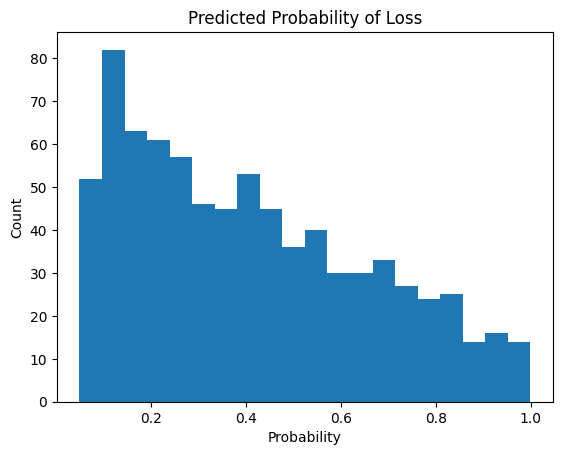

In [ ]:
# Customer Feature Engineering

customer = df.groupby("Customer Name").agg({
    "Sales": "sum",
    "Profit": "sum",
    "Order ID": "nunique"
}).rename(columns={"Order ID": "Orders"})

customer["AOV"] = customer["Sales"] / customer["Orders"]

df["Order Date"] = pd.to_datetime(df["Order Date"])
snapshot_date = df["Order Date"].max() + pd.Timedelta(days=1)

rfm = df.groupby("Customer Name").agg({
    "Order Date": lambda x: (snapshot_date - x.max()).days,
    "Order ID": "count",
    "Sales": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

customer = customer.merge(rfm, left_index=True, right_index=True, how="left")

discount_avg = df.groupby("Customer Name")["Discount"].mean()

customer = customer.merge(
    discount_avg,
    left_index=True,
    right_index=True,
    how="left"
)

customer["Target"] = (customer["Profit"] < 0).astype(int)

# Feature Selection and Train-Test Split

features = [
    "Sales", "Orders", "AOV",
    "Recency", "Frequency", "Monetary", "Discount"
]

X = customer[features]
y = customer["Target"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Data Standardization

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=features,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=features,
    index=X_test.index
)

# Logistic Regression Model Training

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight="balanced", max_iter=1000)
model.fit(X_train_scaled, y_train)

# Model Evaluation

from sklearn.metrics import classification_report

pred = model.predict(X_test_scaled)
print(classification_report(y_test, pred))

# Feature Importance Analysis

importance = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

print("\nFeature Importance:")
print(importance)

importance.plot(
    kind="bar",
    x="Feature",
    y="Coefficient",
    figsize=(6,4),
    legend=False
)

plt.title("Feature Importance (Logistic Regression)")
plt.xticks(rotation=45)
plt.show()

# High-Risk Customer Prediction

customer_scaled = pd.DataFrame(
    scaler.transform(customer[features]),
    columns=features,
    index=customer.index
)

customer["Loss_Prob"] = model.predict_proba(customer_scaled)[:, 1]

high_risk = customer.sort_values(by="Loss_Prob", ascending=False).head(10)

print("\nTop High-Risk Customers:")
display(high_risk)

# Loss Probability Distribution

plt.hist(customer["Loss_Prob"], bins=20)
plt.title("Predicted Probability of Loss")
plt.xlabel("Probability")
plt.ylabel("Count")
plt.show()

In [ ]:
sample = pd.DataFrame({
    "Sales": [500],
    "Orders": [2],
    "AOV": [250],
    "Recency": [30],
    "Frequency": [2],
    "Monetary": [500],
    "Discount": [0.3]
})

sample_scaled = pd.DataFrame(
    scaler.transform(sample),
    columns=features
)

pred = model.predict(sample_scaled)
prob = model.predict_proba(sample_scaled)[0][1]

print(f"Predicted probability of loss: {prob:.2%}")

Predicted probability of loss: 85.01%


In [ ]:
df = df.merge(
    customer[["Loss_Prob"]],
    left_on="Customer Name",
    right_index=True,
    how="left"
)
df.to_csv("superstore_final.csv", index=False)